<a href="https://colab.research.google.com/github/Atharv26j13/2/blob/main/22b_5_6_26_DenBased_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
files = files.upload()

Saving customers.csv to customers (1).csv


In [5]:
import pandas as pd
df = pd.read_csv('customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


In [6]:
x = df.iloc[:,[2,3]].values
x.shape

(200, 2)

In [8]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=3,min_samples=4,metric='euclidean')

model=db.fit(x)
labels=model.labels_
labels

array([ 0,  0,  0,  0, -1,  0,  1,  0, -1, -1, -1,  1, -1,  0,  1,  0,  1,
        0, -1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1,  2,  3,  2, -1,  2,  3,  3,  3,  2,
        3,  3, -1,  2,  2,  2,  4, -1,  2,  4, -1,  4, -1, -1, -1, -1,  4,
       -1, -1,  4, -1, -1, -1, -1, -1,  5, -1, -1,  5, -1, -1, -1,  5, -1,
        5, -1, -1, -1,  6, -1,  7,  6, -1, -1,  7,  6,  7,  6,  7,  7,  6,
        8,  7,  6,  7,  8, -1,  8,  8,  8,  7,  9,  7,  7,  7,  8,  6,  6,
        6, -1,  9,  9,  9, -1, 10,  9,  9, -1,  9, -1,  9, -1, 10, -1, 10,
       -1, 10, -1, -1, -1, 10, 10, 10, 10, 10, -1, 10, 10, 10, -1, 10, -1,
       10, -1, 10, 10, 10, 10, 10, -1, 10, -1, 10, -1, 11, -1, -1, 11, 12,
       -1, 12, 11, 11, -1, 12, -1, 12, -1, -1, -1, 13, -1, 13, -1, 13, -1,
       13, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [9]:
from sklearn import metrics
import numpy as np
sample_cores=np.zeros_like(labels,dtype=bool)
sample_cores[db.core_sample_indices_]=True

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print('No of clusters:', n_clusters)


No of clusters: 14


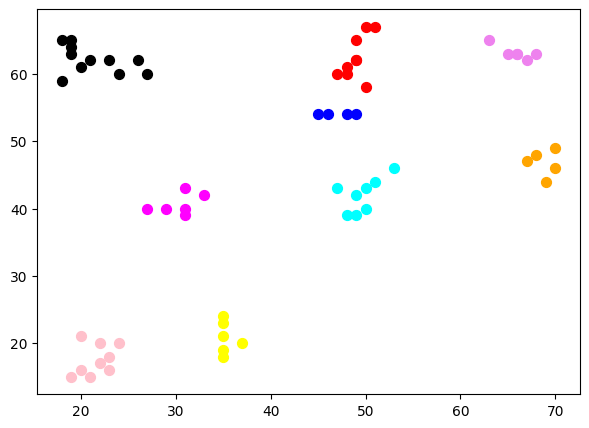

In [18]:
import matplotlib.pyplot as plt

y_means = db.fit_predict(x)
plt.figure(figsize=(7,5))
def Sc(data_points, cluster_label, color):
  # The original code had 'x' in 'y_means == x', which was causing the ValueError
  # It should be 'y_means == cluster_label' to filter points for the current cluster
  plt.scatter(data_points[y_means == cluster_label,0],data_points[y_means == cluster_label, 1],s = 50, c = color)
l = ['pink','yellow','cyan','magenta','orange','blue','red','black','violet']
for i in range(9):
  Sc(x,i,l[i])
plt.show()

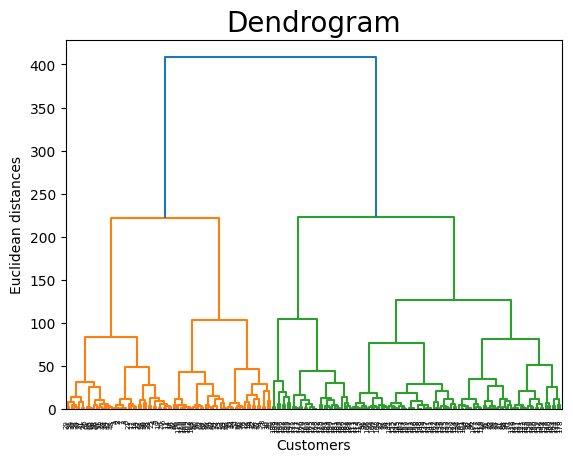

In [19]:
import scipy.cluster.hierarchy as sch
dendrogram=sch.dendrogram(sch.linkage(x,method='ward'))
plt.title('Dendrogram',fontsize=20)
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

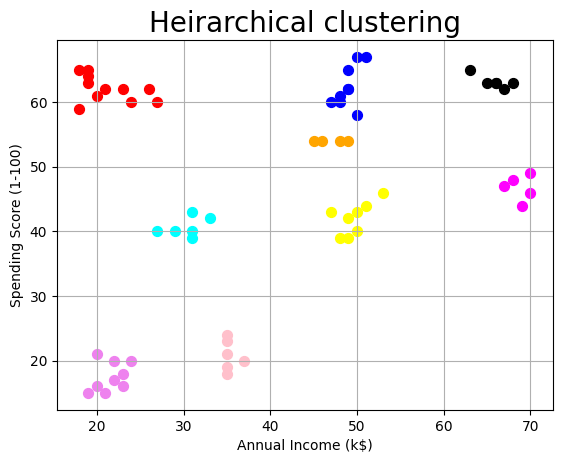

In [30]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=9,metric='euclidean',linkage='ward')
y_hc = hc.fit_predict(x)
for i in range(9):
  Sc(x,i,l[i-1])

plt.title('Heirarchical clustering', fontsize = 20)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid()
plt.show()
